In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving data.csv to data.csv


In [3]:
test_data = pd.read_csv('test.csv')
train_data = pd.read_csv('data.csv')

In [4]:
train_data['rating'].isnull().sum()

np.int64(0)

In [5]:
all_data = pd.concat([train_data, test_data])
n_users = all_data['user_id'].max()
n_items = all_data['item_id'].max()

print(f"\nتعداد کل کاربران: {n_users}")
print(f"تعداد کل فیلم‌ها: {n_items}")


تعداد کل کاربران: 943
تعداد کل فیلم‌ها: 1682


In [30]:
k = 5
alpha = 0.005
beta = 0.02
epochs = 50

print(f"تعداد ویژگی‌های پنهان (k): {k}")
print(f"نرخ یادگیری (alpha): {alpha}")
print(f"ضریب تنظیم (beta): {beta}")
print(f"تعداد تکرارها (epochs): {epochs}")

P = np.random.normal(loc=0, scale=0.1, size=(n_users + 1, k))
Q = np.random.normal(loc=0, scale=0.1, size=(n_items + 1, k))

print(f"\nشکل ماتریس کاربران (P): {P.shape}")
print(f"شکل ماتریس فیلم‌ها (Q): {Q.shape}")

تعداد ویژگی‌های پنهان (k): 5
نرخ یادگیری (alpha): 0.005
ضریب تنظیم (beta): 0.02
تعداد تکرارها (epochs): 50

شکل ماتریس کاربران (P): (944, 5)
شکل ماتریس فیلم‌ها (Q): (1683, 5)


In [31]:
training_history = []

print("شروع فرآیند آموزش مدل...")

for epoch in range(epochs):
  for user_id, item_id, rating, title in train_data.itertuples(index=False):
    user_vector = P[user_id]
    item_vector = Q[item_id]
    prediction = np.dot(user_vector, item_vector)

    error = rating - prediction

    P[user_id] += alpha * (error * item_vector - beta * user_vector)
    Q[item_id] += alpha * (error * user_vector - beta * item_vector)

  total_squared_error = 0

  for user_id, item_id, rating, title in train_data.itertuples(index=False):
    prediction = P[user_id] @ Q[item_id].T # ضرب داخلی
    total_squared_error += (rating - prediction)**2

  train_rmse = np.sqrt(total_squared_error / len(train_data))
  training_history.append(train_rmse)
  print(f"Epoch {epoch+1:02d}/{epochs}  |  Training RMSE: {train_rmse:.4f}")



print("\nفرآیند آموزش با موفقیت به پایان رسید!")




شروع فرآیند آموزش مدل...
Epoch 01/50  |  Training RMSE: 3.6940
Epoch 02/50  |  Training RMSE: 2.9068
Epoch 03/50  |  Training RMSE: 1.6218
Epoch 04/50  |  Training RMSE: 1.2553
Epoch 05/50  |  Training RMSE: 1.1109
Epoch 06/50  |  Training RMSE: 1.0414
Epoch 07/50  |  Training RMSE: 1.0031
Epoch 08/50  |  Training RMSE: 0.9796
Epoch 09/50  |  Training RMSE: 0.9639
Epoch 10/50  |  Training RMSE: 0.9526
Epoch 11/50  |  Training RMSE: 0.9439
Epoch 12/50  |  Training RMSE: 0.9369
Epoch 13/50  |  Training RMSE: 0.9308
Epoch 14/50  |  Training RMSE: 0.9253
Epoch 15/50  |  Training RMSE: 0.9201
Epoch 16/50  |  Training RMSE: 0.9152
Epoch 17/50  |  Training RMSE: 0.9104
Epoch 18/50  |  Training RMSE: 0.9058
Epoch 19/50  |  Training RMSE: 0.9012
Epoch 20/50  |  Training RMSE: 0.8968
Epoch 21/50  |  Training RMSE: 0.8926
Epoch 22/50  |  Training RMSE: 0.8886
Epoch 23/50  |  Training RMSE: 0.8847
Epoch 24/50  |  Training RMSE: 0.8810
Epoch 25/50  |  Training RMSE: 0.8775
Epoch 26/50  |  Training 

In [32]:
print("\nشروع ارزیابی مدل روی داده‌های آزمون...")
test_squared_error = 0


for user_id, item_id, rating, title in test_data.itertuples(index=False):
  user_vector = P[user_id]
  item_vector = Q[item_id]

  prediction = np.dot(user_vector, item_vector)

  prediction = np.clip(prediction, 1, 5)

  test_squared_error += (rating - prediction)**2

test_mse = test_squared_error / len(test_data)

test_rmse = np.sqrt(test_mse)

print(f"\nRMSE نهایی روی داده‌های آزمون: {test_rmse:.4f}")

if test_rmse < 0.94:
    print("تبریک! شما به هدف پروژه (RMSE < 0.94) رسیدید.")
else:
    print("مقدار RMSE هنوز بالاتر از هدف پروژه است. سعی کنید هایپرپارامترها (k, alpha, beta, epochs) را تغییر دهید.")


شروع ارزیابی مدل روی داده‌های آزمون...

RMSE نهایی روی داده‌های آزمون: 0.9303
تبریک! شما به هدف پروژه (RMSE < 0.94) رسیدید.


In [33]:
print("\nشروع تحلیل نتایج و محاسبه مقادیر تکین...")

R_hat = Q[1:] @ P[1:].T

print(f"ماتریس کامل پیش‌بینی R_hat با شکل {R_hat.shape} ساخته شد.")

U, s, Vt = np.linalg.svd(R_hat, full_matrices=False)

print("تجزیه SVD با موفقیت روی R_hat انجام شد.")
print(f"تعداد مقادیر تکین به دست آمده: {len(s)}")

print("\n۱۰ مقدار تکین اول (به ترتیب نزولی):")
print(s[:10])


شروع تحلیل نتایج و محاسبه مقادیر تکین...
ماتریس کامل پیش‌بینی R_hat با شکل (1682, 943) ساخته شد.
تجزیه SVD با موفقیت روی R_hat انجام شد.
تعداد مقادیر تکین به دست آمده: 943

۱۰ مقدار تکین اول (به ترتیب نزولی):
[3.88000930e+03 2.27708440e+02 1.20998767e+02 1.17080800e+02
 1.03517977e+02 3.90149103e-12 3.53072032e-12 3.44614053e-12
 3.29142865e-12 3.11300588e-12]


In [34]:
print("\nمحاسبه انرژی و سهم هر مؤلفه...")

energy = s**2
total_energy = np.sum(energy)
explained_variance_ratio = energy / total_energy
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\nتحلیل برای ۱۰ مؤلفه اول:")
print("="*30)
for i in range(10):
  print(f"مؤلفه {i+1:02d}:")
  print(f"  - سهم از کل واریانس: {explained_variance_ratio[i]:.2%}")
  print(f"  - واریانس تجمعی: {cumulative_variance[i]:.2%}")



محاسبه انرژی و سهم هر مؤلفه...

تحلیل برای ۱۰ مؤلفه اول:
مؤلفه 01:
  - سهم از کل واریانس: 99.40%
  - واریانس تجمعی: 99.40%
مؤلفه 02:
  - سهم از کل واریانس: 0.34%
  - واریانس تجمعی: 99.74%
مؤلفه 03:
  - سهم از کل واریانس: 0.10%
  - واریانس تجمعی: 99.84%
مؤلفه 04:
  - سهم از کل واریانس: 0.09%
  - واریانس تجمعی: 99.93%
مؤلفه 05:
  - سهم از کل واریانس: 0.07%
  - واریانس تجمعی: 100.00%
مؤلفه 06:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 07:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 08:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 09:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 10:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%


(0.0, 1.05)

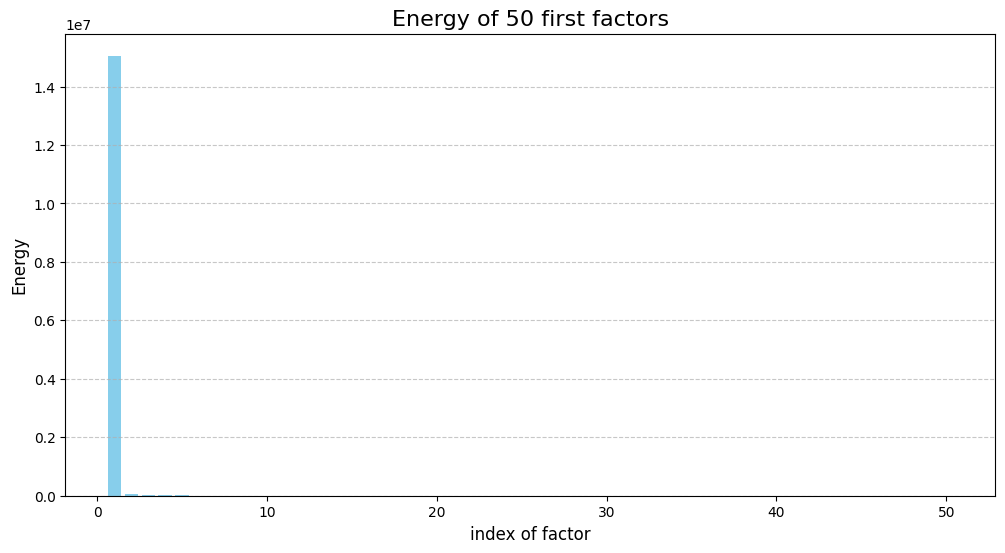

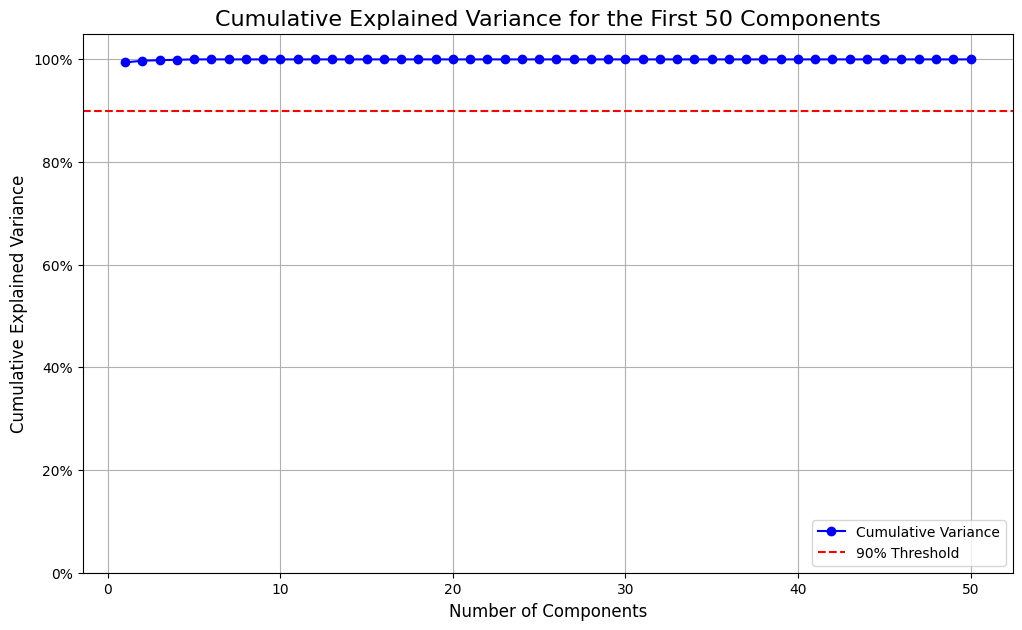

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np


n_components_to_plot = 50
x_axis = range(1, n_components_to_plot + 1)

# --- نمودار انرژی برای ۵۰ مؤلفه اول ---
plt.figure(figsize=(12, 6))
plt.bar(x_axis, energy[:n_components_to_plot], color='skyblue')
plt.title(f'Energy of {n_components_to_plot} first factors', fontsize=16)
plt.xlabel('index of factor', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)



# --- نمودار واریانس تجمعی برای ۵۰ مؤلفه اول ---
plt.figure(figsize=(12, 7))

plt.plot(x_axis, cumulative_variance[:n_components_to_plot], 'b-o', label='Cumulative Variance')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.title(f'Cumulative Explained Variance for the First {n_components_to_plot} Components', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(loc='lower right')
plt.grid(True)
plt.ylim(0, 1.05)


--- شروع آموزش برای k = 5 ---
--- پایان آموزش برای k = 5 | RMSE نهایی: 0.9317 ---

--- شروع آموزش برای k = 10 ---
--- پایان آموزش برای k = 10 | RMSE نهایی: 0.9273 ---

--- شروع آموزش برای k = 15 ---
--- پایان آموزش برای k = 15 | RMSE نهایی: 0.9300 ---

--- شروع آموزش برای k = 20 ---
--- پایان آموزش برای k = 20 | RMSE نهایی: 0.9411 ---

--- شروع آموزش برای k = 25 ---
--- پایان آموزش برای k = 25 | RMSE نهایی: 0.9375 ---

--- شروع آموزش برای k = 30 ---
--- پایان آموزش برای k = 30 | RMSE نهایی: 0.9350 ---

--- شروع آموزش برای k = 40 ---
--- پایان آموزش برای k = 40 | RMSE نهایی: 0.9464 ---

--- شروع آموزش برای k = 50 ---
--- پایان آموزش برای k = 50 | RMSE نهایی: 0.9390 ---


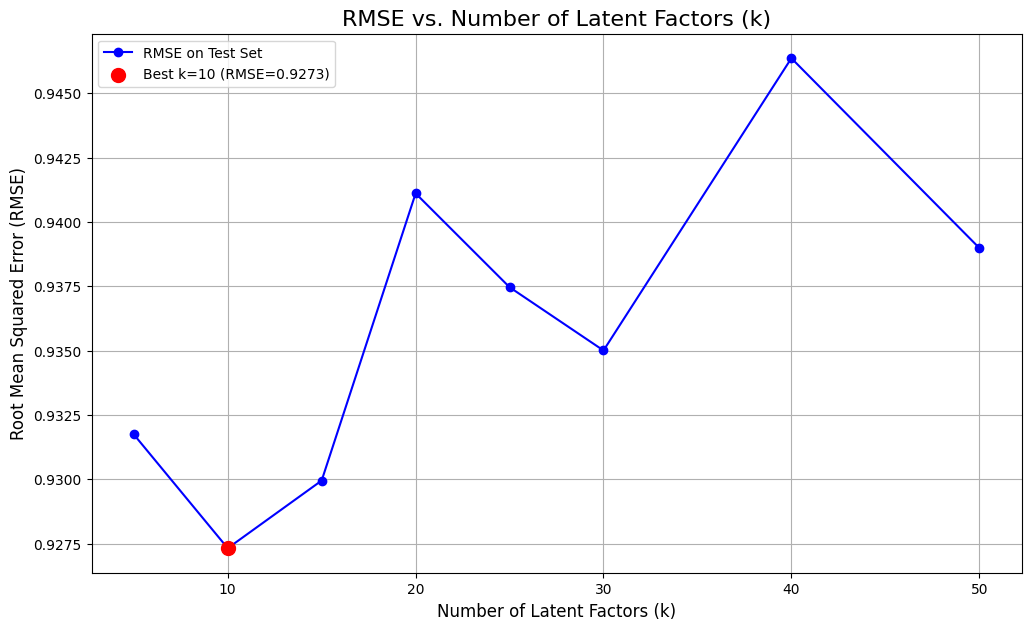

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




k_values = [5, 10, 15, 20, 25, 30, 40, 50] # لیستی از k های مختلف برای تست
results = {} # دیکشنری برای ذخیره نتایج: {k: rmse}

# هایپرپارامترهای ثابت
alpha = 0.005
beta = 0.02
epochs = 30 # برای سرعت بیشتر، تعداد تکرار را در این آزمایش کم می‌کنیم


# --- بخش ۳: حلقه اصلی برای آزمایش k های مختلف ---
for k in k_values:
    print(f"\n--- شروع آموزش برای k = {k} ---")

    # ۱. مقداردهی اولیه P و Q با k جدید
    P = np.random.normal(loc=0, scale=0.1, size=(n_users + 1, k))
    Q = np.random.normal(loc=0, scale=0.1, size=(n_items + 1, k))

    # ۲. حلقه آموزش مدل
    for epoch in range(epochs):
        for user_id, item_id, rating, title in train_data.itertuples(index=False):
            user_vector = P[user_id]
            item_vector = Q[item_id]
            prediction = np.dot(user_vector, item_vector)
            error = rating - prediction
            P[user_id] += alpha * (error * item_vector - beta * user_vector)
            Q[item_id] += alpha * (error * user_vector - beta * item_vector)

    # ۳. ارزیابی روی داده‌های آزمون
    test_squared_error = 0
    for user_id, item_id, rating, title in test_data.itertuples(index=False):
        prediction = np.dot(P[user_id], Q[item_id])
        prediction = np.clip(prediction, 1, 5)
        test_squared_error += (rating - prediction)**2

    test_rmse = np.sqrt(test_squared_error / len(test_data))

    # ۴. ذخیره نتیجه
    results[k] = test_rmse
    print(f"--- پایان آموزش برای k = {k} | RMSE نهایی: {test_rmse:.4f} ---")


# --- بخش ۴: رسم نمودار نتایج ---
# پیدا کردن بهترین k (k که کمترین rmse را داشته)
best_k = min(results, key=results.get)
best_rmse = results[best_k]

# استخراج مقادیر برای رسم
k_list = list(results.keys())
rmse_list = list(results.values())

plt.figure(figsize=(12, 7))
plt.plot(k_list, rmse_list, 'b-o', label='RMSE on Test Set')
plt.title('RMSE vs. Number of Latent Factors (k)', fontsize=16)
plt.xlabel('Number of Latent Factors (k)', fontsize=12)
plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.grid(True)

# هایلایت کردن بهترین نقطه
plt.scatter(best_k, best_rmse, color='r', s=100, zorder=5, label=f'Best k={best_k} (RMSE={best_rmse:.4f})')
plt.legend()

In [36]:
all_movies_df = pd.concat([train_data[['item_id', 'title']], test_data[['item_id', 'title']]])

unique_movies_df = all_movies_df.drop_duplicates(subset=['item_id'])
movie_titles = unique_movies_df.set_index('item_id')['title'].to_dict()

print("دیکشنری نام فیلم‌ها با موفقیت ساخته شد.")

def analyze_movie_factors(factor_number, Q_matrix, titles_dict, n_extremes=5):
  print(f"\n===== تحلیل مؤلفه فیلم شماره {factor_number} =====")
  factor_index = factor_number - 1
  movie_factor_scores = Q_matrix[:, factor_index]
  sorted_movie_indices = np.argsort(movie_factor_scores)

  print(f"\n--- فیلم‌ها در انتهای منفی (Negative Pole) ---")

  negative_movie_ids = sorted_movie_indices[1:n_extremes+1]

  for item_id in negative_movie_ids:
        title = titles_dict.get(item_id, f"ID: {item_id}")
        print(f"  - {title} (امتیاز: {movie_factor_scores[item_id]:.2f})")

  print(f"\n--- فیلم‌ها در انتهای مثبت (Positive Pole) ---")
  positive_movie_ids = sorted_movie_indices[-n_extremes:]
  # برعکس کردن لیست برای نمایش از بیشترین به کمترین
  for item_id in reversed(positive_movie_ids):
      title = titles_dict.get(item_id, f"ID: {item_id}")
      print(f"  - {title} (امتیاز: {movie_factor_scores[item_id]:.2f})")
  print("="*35)


# اجرای تحلیل برای سه مؤلفه اول
for i in range(1, 4):
    analyze_movie_factors(i, Q, movie_titles)



دیکشنری نام فیلم‌ها با موفقیت ساخته شد.

===== تحلیل مؤلفه فیلم شماره 1 =====

--- فیلم‌ها در انتهای منفی (Negative Pole) ---
  - Trainspotting (1996) (امتیاز: -1.16)
  - Heavenly Creatures (1994) (امتیاز: -1.08)
  - Ed Wood (1994) (امتیاز: -1.05)
  - Cook the Thief His Wife & Her Lover, The (1989) (امتیاز: -1.00)
  - Leaving Las Vegas (1995) (امتیاز: -0.95)

--- فیلم‌ها در انتهای مثبت (Positive Pole) ---
  - Twister (1996) (امتیاز: 1.43)
  - Saint, The (1997) (امتیاز: 1.43)
  - Jungle2Jungle (1997) (امتیاز: 1.39)
  - Conspiracy Theory (1997) (امتیاز: 1.29)
  - Independence Day (ID4) (1996) (امتیاز: 1.28)

===== تحلیل مؤلفه فیلم شماره 2 =====

--- فیلم‌ها در انتهای منفی (Negative Pole) ---
  - Cold Comfort Farm (1995) (امتیاز: -1.58)
  - Aliens (1986) (امتیاز: -1.55)
  - Ben-Hur (1959) (امتیاز: -1.50)
  - Ran (1985) (امتیاز: -1.50)
  - Nosferatu (Nosferatu, eine Symphonie des Grauens) (1922) (امتیاز: -1.48)

--- فیلم‌ها در انتهای مثبت (Positive Pole) ---
  - Scream (1996) (امتیاز: 0.67

### ## تحلیل مؤلفه ۱

* **قطب منفی (-):** این قطب شامل فیلم‌های تحسین‌شده، مستقل و اغلب تاریک و خاص‌پسند دهه ۹۰ است. فیلم‌هایی مانند `Trainspotting`، `Ed Wood` و `Leaving Las Vegas` همگی آثاری هستند که توسط منتقدان ستایش شده‌اند اما شاید برای عموم مخاطبان جریان اصلی نباشند.
* **قطب مثبت (+):** این قطب به وضوح شامل فیلم‌های پرفروش، اکشن و سرگرم‌کننده دهه ۹۰ است. `Twister` و `Independence Day` فیلم‌های بلاک‌باستر و مبتنی بر جلوه‌های ویژه هستند و `The Saint` و `Conspiracy Theory` اکشن‌های جریان اصلی با ستاره‌های سینما هستند.

**فرضیه برای مؤلفه ۱:** این عامل به نظر می‌رسد یک طیف از **"فیلم‌های مستقل و تحسین‌شده توسط منتقدان" (-)** تا **"بلاک‌باسترهای اکشن و پرفروش" (+)** را نشان می‌دهد. می‌توان آن را محور **"هنری/مستقل در مقابل تجاری/بلاک‌باستر"** نامید.

---
### ## تحلیل مؤلفه ۲

* **قطب منفی (-):** این قطب مجموعه‌ای از شاهکارهای سینمایی و فیلم‌های کلاسیکِ حماسی است. `Ben-Hur` و `Ran` فیلم‌های حماسی بزرگ هستند، `Aliens` یک کلاسیک اکشن/ترسناک است و `Nosferatu` از پایه‌های سینمای صامت و ترسناک است. این‌ها فیلم‌های "مهم" و "بزرگ" تاریخ سینما هستند.
* **قطب مثبت (+):** این قطب بیشتر شامل **کمدی‌ها و فیلم‌های ترسناک عامه‌پسند دهه ۹۰** است. `Scream` و دنباله‌اش و `Dumb & Dumber` نمونه‌های بارز این دسته هستند. این فیلم‌ها عموماً سرگرم‌کننده و معاصر (نسبت به زمان ساخت دیتاست) هستند و مقیاس حماسی ندارند.

**فرضیه برای مؤلفه ۲:** این عامل به نظر می‌رسد **"آثار کلاسیک، حماسی و تاریخی سینما" (-)** را از **"فیلم‌های ژانر معاصر (کمدی/ترسناک دهه ۹۰)" (+)** جدا می‌کند. این یک محور **"کلاسیک در مقابل معاصر"** است.

---
### ## تحلیل مؤلفه ۳

* **قطب منفی (-):** این قطب به طور مشخصی شامل **کمدی‌های رمانتیک، موزیکال‌ها و فیلم‌های حال‌خوب‌کن** است. `The Sound of Music`, `While You Were Sleeping` و `The Mask` همگی در این دسته قرار می‌گیرند که فضایی شادتر و سبُک‌تر دارند.
* **قطب مثبت (+):** در مقابل، این قطب به وضوح شامل **درام‌های تاریک، جنایی، خشن و جدی** است. `Reservoir Dogs` و `Lost Highway` نمونه‌های بارز سینمای جناییِ مستقل و استایلیزه هستند و `The Ice Storm` و `Crash` درام‌های بسیار جدی و تلخ محسوب می‌شوند.

**فرضیه برای مؤلفه ۳:** این عامل یک تمایز بسیار واضح را نشان می‌دهد و به نظر می‌رسد محور **"فضای فیلم"** باشد: از **"کمدی‌های شاد و فیلم‌های حال‌خوب‌کن" (-)** تا **"درام‌های تاریک، خشن و جدی" (+)**.